# EV Curves with Quantum ESPRESSO

**Prerequisites**
- `pw.x` must be available on `$PATH` (or pass the full path via `qe_command`)
- A UPF pseudopotential file for the element of interest
- A QE input template file with `&CONTROL`, `&SYSTEM`, `&ELECTRONS` namelists and `K_POINTS`
  (atomic positions and cell will be filled in automatically by ASE)

In [1]:
import matplotlib.pyplot as plt
from conceptual_dictionary import ConceptualDict
from semantic_workflows.pyiron.build import bulk
from semantic_workflows.pyiron.evcurves import relax_structure, calculate_ev_curves
from pyiron_workflow import Workflow

## Setup

Edit the paths and parameters below to match your system.

In [2]:
# Path to the QE input template (contains namelists + K_POINTS, no atomic structure)
input_template = "qe_ref/pw.si.scf.ref"

# Pseudopotential files: {element_symbol: path_to_UPF}
pseudopotentials = {"Si": "qe_ref/Si.pbe-n-rrkjus_psl.1.0.0.UPF"}

# QE executable (full path if not on $PATH)
qe_command = "pw.x"

cd = ConceptualDict()

## Run the workflow

In [3]:
wf = Workflow('qe_ev')
wf.structure = bulk('Si', crystalstructure='diamond', a=5.43, cubic=True, cdict=cd)
wf.relaxed_structure = relax_structure(
    wf.structure,
    engine="qe",
    input_template=input_template,
    pseudopotentials=pseudopotentials,
    working_dir="qe_relax_run",
    qe_command=qe_command,
    cdict=cd,
)
wf.ev_curves = calculate_ev_curves(
    wf.relaxed_structure.outputs.final_structure,
    engine="qe",
    vol_range=0.1,
    num_of_points=7,
    input_template=input_template,
    pseudopotentials=pseudopotentials,
    working_dir="qe_ev_run",
    qe_command=qe_command,
    cdict=cd,
)

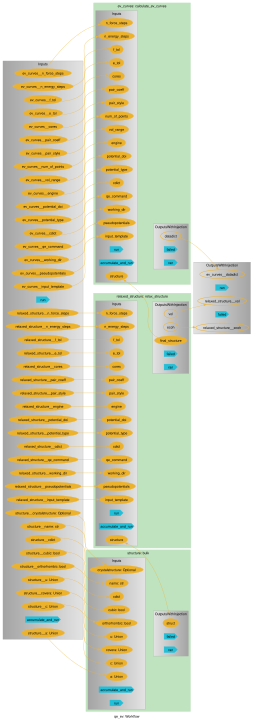

In [5]:
wf.draw(rankdir='LR', size=(10, 10))

In [ ]:
res = wf.run()

In [ ]:
# 4. Export semantic metadata
cd.to_yaml("qe_evcurve.yaml")